# PHYS 449 - Homework 3, Question 1

**Student Name:** Allen Mathew \
**Student ID:** 20964892 \
**Due Date:** Thursday, September 25, 3:00pm 

*ChatGPT was used to help generate the code and some formulas for the questions*
- - -


1. Produce a dataset $\mathcal{D}$ from a $8 × 8$ Ising model. Each element of the dataset is a vector of spin configurations (drawn from the Boltzmann distribution at equilibrium at temperature $T$), and it’s respective classification of $FM$ or $PM$. The dataset should consist of $i.i.d.$ sampled configurations for $T_i$ evenly distributed in the interval $[1.0, 3.5]$. Label each configuration vector sampled for $T < 2.269$ as $FM$, and those for $T > 2.269$ as $PM$. Build a data set of size $|\mathcal{D}|=10^4$, and divide your dataset into 80% training and 20% validation.

In [1]:
# === Cell 1: Dataset D (8x8), labels, and 80/20 split ===
import numpy as np
from tqdm import tqdm

# Assignment constants (from HW3 prompt)
TC = 2.269            # critical temperature
T_MIN, T_MAX = 1.0, 3.5
L = 8                 # lattice size for Q1(a)
TOTAL_SAMPLES = 10_000
TRAIN_FRAC = 0.80     # 80% training, 20% validation

# Thinning to approximate i.i.d. samples (requested by prompt):contentReference[oaicite:4]{index=4}
BURN_IN_SWEEPS = 200
THINNING_SWEEPS = 20

# --- Try importing your MonteCarlo helpers; fallback if not found ---:contentReference[oaicite:5]{index=5}
use_fallback = False
try:
    from MonteCarlo import init_spins, total_energy, energy_difference
except Exception:
    use_fallback = True

if use_fallback:
    def init_spins(L):
        return np.random.choice([-1, 1], size=(L, L))

    def total_energy(spins, L, J=1.0):
        E = 0
        for i in range(L):
            for j in range(L):
                E += spins[i, j] * spins[i, (j + 1) % L]
                E += spins[i, j] * spins[(i + 1) % L, j]
        return -J * E

    def energy_difference(spins, L, J, x, y):
        sigma_old = spins[x, y]
        s = (spins[(x + 1) % L, y] + spins[(x - 1) % L, y] +
             spins[x, (y + 1) % L] + spins[x, (y - 1) % L])
        return 2.0 * J * sigma_old * s

def metropolis_accept(dE, T):
    if dE < 0: 
        return True
    return np.exp(-dE / T) > np.random.rand()

def do_sweeps(spins, T, sweeps, J=1.0):
    L = spins.shape[0]
    N = L * L
    E = total_energy(spins, L, J)
    for _ in range(sweeps):
        for _ in range(N):
            x, y = np.random.randint(0, L, size=2)
            dE = energy_difference(spins, L, J, x, y)
            if metropolis_accept(dE, T):
                spins[x, y] *= -1
                E += dE
    return E

def sample_iid_configs(L, T, n_samples, burn=BURN_IN_SWEEPS, thin=THINNING_SWEEPS, J=1.0):
    """Burn-in + thinning to approximate i.i.d. equilibrium samples at T."""
    spins = init_spins(L)
    _ = do_sweeps(spins, T, burn, J)
    cfgs = []
    for _ in range(n_samples):
        _ = do_sweeps(spins, T, thin, J)
        cfgs.append(spins.copy())
    return cfgs

def label_from_T(T, Tc=TC):
    # HW3: FM if T < Tc; PM if T > Tc (skip exact Tc):contentReference[oaicite:6]{index=6}
    if T < Tc: return "FM"
    if T > Tc: return "PM"
    return None

def spins_to_vec(spins):
    return spins.reshape(-1).astype(np.int8)  # {-1,+1} flattened

def build_dataset(L=8, total=10_000, Tmin=1.0, Tmax=3.5, n_temps=25, seed=42):
    np.random.seed(seed)
    Ts = np.linspace(Tmin, Tmax, n_temps)
    Ts = np.array([T for T in Ts if abs(T - TC) > 1e-8])  # avoid exact Tc boundary
    n_temps = len(Ts)
    per_T = total // n_temps
    leftover = total - per_T * n_temps

    X_list, y_list, T_list = [], [], []
    for i, T in enumerate(tqdm(Ts, desc="Temps for D")):
        n_here = per_T + (1 if i < leftover else 0)
        lbl = label_from_T(T)
        if lbl is None: 
            continue
        cfgs = sample_iid_configs(L, T, n_here)
        for cfg in cfgs:
            X_list.append(spins_to_vec(cfg))
            y_list.append(lbl)
            T_list.append(T)

    X = np.vstack(X_list)
    y = np.array(y_list, dtype=object)
    Tarr = np.array(T_list, dtype=np.float32)

    # Shuffle & 80/20 split (train/val)
    idx = np.random.permutation(len(X))
    X, y, Tarr = X[idx], y[idx], Tarr[idx]

    n_train = int(round(TRAIN_FRAC * len(X)))
    X_train, y_train = X[:n_train], y[:n_train]
    X_val,   y_val   = X[n_train:], y[n_train:]

    print(f"L={L}, |D|={len(X)} -> train={len(X_train)}, val={len(X_val)}")
    return (X_train, y_train), (X_val, y_val), Tarr

# ---- Build D and split ----
(X_train, y_train), (X_val, y_val), T_used = build_dataset(
    L=L, total=TOTAL_SAMPLES, Tmin=T_MIN, Tmax=T_MAX, n_temps=25, seed=123
)

# Optional: persist for reuse
np.savez_compressed("ising8_dataset_trainval.npz",
                    X_train=X_train, y_train=y_train, X_val=X_val, y_val=y_val, T=T_used)
print("Saved dataset to ising8_dataset_trainval.npz")

Temps for D: 100%|██████████| 25/25 [03:23<00:00,  8.15s/it]

L=8, |D|=10000 -> train=8000, val=2000
Saved dataset to ising8_dataset_trainval.npz


(a) Build a (hard) KNN classifier for the dataset, using the Hamming distance as your metric. Find the best value of the “hyperparameter” $K$ (the closest training points) by optimizing the accuracy on the validation set.

KNN(K=21): 100%|██████████| 2000/2000 [00:01<00:00, 1252.76it/s]


Validation accuracy by K:
K= 1: acc=0.8100
K= 3: acc=0.8305
K= 5: acc=0.8270
K= 7: acc=0.8290
K= 9: acc=0.8310
K=11: acc=0.8270
K=15: acc=0.8220
K=21: acc=0.8180

Best K = 9 with validation accuracy = 0.8310


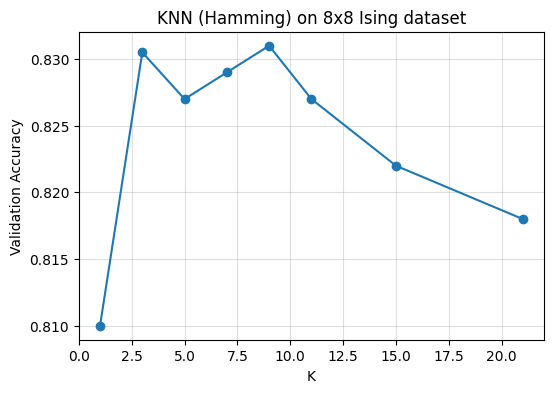

In [2]:
# === Cell 2: Q1(a) — hard KNN with Hamming distance; tune K on validation ===
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

# Load if you ran Cell 1 earlier (or reuse variables directly)
try:
    data = np.load("ising8_dataset_trainval.npz", allow_pickle=True)
    X_train = data["X_train"]; y_train = data["y_train"]
    X_val   = data["X_val"];   y_val   = data["y_val"]
except Exception:
    pass  # assume X_train, y_train, X_val, y_val exist in memory

def knn_predict_hard_hamming(X_train, y_train, X_query, K=5):
    """
    Pure NumPy KNN (hard vote) with Hamming distance on {-1,+1} vectors.
    Hamming = fraction of differing components.
    """
    preds = []
    for x in tqdm(X_query, desc=f"KNN(K={K})"):
        # vectorized Hamming distances to all training samples
        dists = np.mean(X_train != x, axis=1)
        nn_idx = np.argpartition(dists, K)[:K]
        nn_labels = y_train[nn_idx]

        fm = np.sum(nn_labels == "FM")
        pm = K - fm
        if fm > pm:
            preds.append("FM")
        elif pm > fm:
            preds.append("PM")
        else:
            # tie-breaker: nearest neighbor label
            preds.append(y_train[nn_idx[np.argmin(dists[nn_idx])]])
    return np.array(preds, dtype=object)

def accuracy(y_true, y_pred):
    return float(np.mean(y_true == y_pred))

K_GRID = [1, 3, 5, 7, 9, 11, 15, 21]

val_results = []
best = {"K": None, "acc": -1.0}
for K in K_GRID:
    y_hat = knn_predict_hard_hamming(X_train, y_train, X_val, K=K)
    acc = accuracy(y_val, y_hat)
    val_results.append((K, acc))
    if acc > best["acc"]:
        best = {"K": K, "acc": acc}

print("Validation accuracy by K:")
for K, acc in val_results:
    print(f"K={K:>2d}: acc={acc:.4f}")
print(f"\nBest K = {best['K']} with validation accuracy = {best['acc']:.4f}")

# Plot K vs accuracy
plt.figure(figsize=(6,4))
plt.plot([k for k,_ in val_results], [a for _,a in val_results], marker='o')
plt.xlabel("K")
plt.ylabel("Validation Accuracy")
plt.title("KNN (Hamming) on 8x8 Ising dataset")
plt.grid(True, alpha=0.4)
plt.show()


(b) Increase both your dataset size and the size of the lattice. What is the largest lattice size that you can get reasonable performance of your KNN classifier on, for your own compute availabilty?


=== L=8, |D|=10000 ===


Temps for D: 100%|██████████| 25/25 [03:21<00:00,  8.06s/it]


L=8, |D|=10000 -> train=8000, val=2000


KNN(K=9): 100%|██████████| 2000/2000 [00:01<00:00, 1332.92it/s]


Best K=9, val acc=0.8310

=== L=8, |D|=15000 ===


...

Best K=5, val acc=0.8355

=== L=16, |D|=15000 ===


Temps for D: 100%|██████████| 25/25 [18:59<00:00, 45.59s/it]


L=16, |D|=15000 -> train=12000, val=3000


KNN(K=9): 100%|██████████| 3000/3000 [00:11<00:00, 252.54it/s]


Best K=5, val acc=0.8520


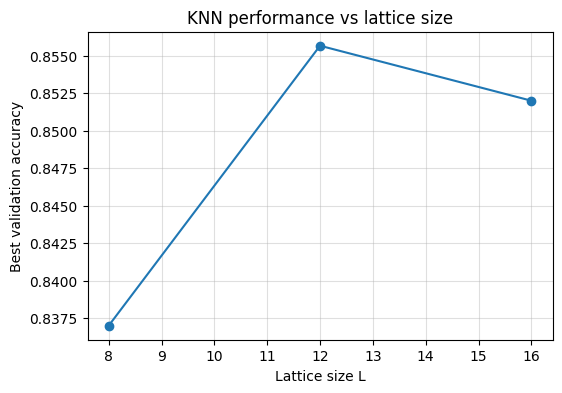


Summary (L, |D|, best K, best acc):
(8, 10000, 9, 0.831)
(8, 15000, 7, 0.837)
(12, 10000, 5, 0.8265)
(12, 15000, 5, 0.8556666666666667)
(16, 10000, 5, 0.8355)
(16, 15000, 5, 0.852)

Largest L with 'reasonable' (≥0.80) accuracy: L = 16


In [3]:
# === Cell 3: Q1(b) — scale L and |D|; measure validation accuracy ===
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# Reuse dataset builder & KNN from prior cells:
# - build_dataset(...)
# - knn_predict_hard_hamming(...)
# - accuracy(...)

def run_scaling_experiment(
    L_list=(8, 12, 16),
    total_list=(10_000, 15_000, 20_000),
    n_temps=25,
    K_eval=(5, 7, 9),      # small grid for speed
    train_frac=0.80,
    seed=123
):
    results = []  # rows of (L, total, bestK, bestAcc)

    for L in L_list:
        for total in total_list:
            print(f"\n=== L={L}, |D|={total} ===")
            (X_tr, y_tr), (X_va, y_va), _ = build_dataset(
                L=L, total=total, Tmin=T_MIN, Tmax=T_MAX, n_temps=n_temps, seed=seed
            )

            best = {"K": None, "acc": -1.0}
            for K in K_eval:
                y_hat = knn_predict_hard_hamming(X_tr, y_tr, X_va, K=K)
                acc = accuracy(y_va, y_hat)
                if acc > best["acc"]:
                    best = {"K": K, "acc": acc}

            print(f"Best K={best['K']}, val acc={best['acc']:.4f}")
            results.append((L, total, best["K"], best["acc"]))

    return results

results = run_scaling_experiment(
    L_list=(8, 12, 16), 
    total_list=(10_000, 15_000), 
    K_eval=(5, 7, 9)
)

# Summarize and plot "best acc vs L"
Ls = sorted(set([r[0] for r in results]))
best_acc_by_L = {L: max([r[3] for r in results if r[0] == L]) for L in Ls}

plt.figure(figsize=(6,4))
plt.plot(Ls, [best_acc_by_L[L] for L in Ls], marker='o')
plt.xlabel("Lattice size L")
plt.ylabel("Best validation accuracy")
plt.title("KNN performance vs lattice size")
plt.grid(True, alpha=0.4)
plt.show()

print("\nSummary (L, |D|, best K, best acc):")
for row in results:
    print(row)

# Heuristic: pick "largest reasonable L" where val acc remains decent (e.g., ≥ ~0.8)
reasonable = [L for L in Ls if best_acc_by_L[L] >= 0.80]
if len(reasonable):
    print(f"\nLargest L with 'reasonable' (≥0.80) accuracy: L = {max(reasonable)}")
else:
    print("\nNo L met the 'reasonable' threshold; consider increasing |D| or adjusting K.")
